# Delivery Time Estimation — iDICE Founders Lab Capstone (Data Science Track)

**Problem:** Logistics ETAs are unreliable — customers and dispatch teams cannot
trust the delivery-time estimates they're given, which hurts customer experience
and route/fleet planning.

**Goal (MVP):** Build a regression model that predicts delivery time (in minutes)
for a delivery order, using order, route, rider and environmental features, then
evaluate the model honestly (including where it fails) so the estimate can be
trusted enough to show to a user.

**Scope of this notebook**
1. Data preparation (synthetic, Nigeria / North-West logistics context)
2. Exploratory data analysis
3. Feature engineering & preprocessing pipeline
4. Model training (baseline → tuned models)
5. Error analysis (where and why the model is wrong)
6. Evaluation & model selection
7. Save the final model artifact

> **Note on data:** No public/real delivery dataset was available for this
> capstone, so a *synthetic but realistic* dataset is simulated below, using
> distributions and cause-effect relationships (distance, road condition,
> weather, traffic, rider experience, multi-stop routes) that mirror real
> last-mile delivery conditions in Kebbi State / North-West Nigeria — paved vs.
> unpaved roads, harmattan dust, rainy season, and patchy network coverage for
> live tracking. Swap in a real operations dataset later using the same schema
> (see README) and the rest of the pipeline should work unchanged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ImportError: DLL load failed while importing properties: An Application Control policy has blocked this file.

## 1. Data Preparation

### 1.1 Simulate a realistic delivery dataset

Each row is one completed delivery order. Features are grouped into:
- **Route**: origin hub, destination town, distance, road condition
- **Order**: package weight, number of stops (multi-drop), order type
- **Context**: time of day, day of week, weather, traffic level, network signal
- **Rider**: vehicle type, years of experience

The target `delivery_time_minutes` is generated from a plausible underlying
formula (speed by vehicle/road, handling time per stop, weather/traffic
penalties, rider-experience effect) plus random noise, so relationships are
realistic but not perfectly linear or noise-free — same as real operations data.

In [2]:
N = 6000

towns = {
    "Birnin Kebbi": 0,      # hub itself, distance offset 0
    "Argungu": 65,
    "Bunza": 45,
    "Kamba": 140,
    "Zuru": 180,
    "Jega": 55,
    "Yauri": 160,
    "Aliero": 35,
}

vehicle_types = ["Motorcycle", "Keke (Tricycle)", "Van", "Truck"]
# base speed (km/h) on a GOOD paved road, before conditions/traffic penalties
vehicle_base_speed = {"Motorcycle": 55, "Keke (Tricycle)": 35, "Van": 60, "Truck": 45}
# handling time added per extra stop (minutes) - smaller/nimbler vehicles are faster to unload
vehicle_stop_time = {"Motorcycle": 4, "Keke (Tricycle)": 6, "Van": 9, "Truck": 14}

weather_options = ["Clear", "Rain", "Harmattan Dust"]
weather_speed_penalty = {"Clear": 1.00, "Rain": 0.65, "Harmattan Dust": 0.80}

road_conditions = ["Paved", "Unpaved"]
road_speed_penalty = {"Paved": 1.00, "Unpaved": 0.55}

traffic_levels = ["Low", "Medium", "High"]
traffic_speed_penalty = {"Low": 1.00, "Medium": 0.80, "High": 0.55}

order_types = ["Parcel", "Food", "Documents", "Bulk Goods"]

rows = []
for i in range(N):
    dest = np.random.choice(list(towns.keys()), p=[0.30, 0.14, 0.14, 0.10, 0.08, 0.12, 0.06, 0.06])
    base_km = towns[dest]
    # add local intra-town distance for the "last mile" leg (1-12 km) so distance is never 0
    distance_km = max(1.5, np.random.normal(loc=base_km if base_km > 0 else 6, scale=max(2, base_km * 0.12)))
    distance_km = round(distance_km, 1)

    vehicle = np.random.choice(vehicle_types, p=[0.45, 0.30, 0.18, 0.07])
    weather = np.random.choice(weather_options, p=[0.60, 0.20, 0.20])
    road = np.random.choice(road_conditions, p=[0.55, 0.45]) if base_km > 0 else np.random.choice(road_conditions, p=[0.85, 0.15])
    traffic = np.random.choice(traffic_levels, p=[0.45, 0.35, 0.20])
    order_type = np.random.choice(order_types, p=[0.40, 0.30, 0.15, 0.15])

    num_stops = np.random.choice([0, 1, 2, 3, 4], p=[0.55, 0.22, 0.13, 0.07, 0.03])  # extra stops before final drop
    package_weight_kg = round(max(0.2, np.random.exponential(scale=4.0)), 1)
    if order_type == "Bulk Goods":
        package_weight_kg = round(package_weight_kg + np.random.uniform(10, 40), 1)

    rider_experience_years = round(max(0, np.random.gamma(shape=2.0, scale=1.3)), 1)

    hour = np.random.choice(range(6, 22))
    time_of_day = (
        "Morning" if 6 <= hour < 11 else
        "Midday" if 11 <= hour < 15 else
        "Afternoon" if 15 <= hour < 18 else
        "Evening"
    )
    day_of_week = np.random.choice(
        ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    )
    is_weekend = day_of_week in ["Saturday", "Sunday"]

    # network signal strength affects live tracking / dispatch confirmation delay, not raw travel time
    network_signal = np.random.choice(["Strong", "Weak", "No Signal"], p=[0.45, 0.40, 0.15])
    network_delay = {"Strong": 0, "Weak": 3, "No Signal": 7}[network_signal]

    # ---- underlying "true" process that generates delivery time ----
    effective_speed = (
        vehicle_base_speed[vehicle]
        * weather_speed_penalty[weather]
        * road_speed_penalty[road]
        * traffic_speed_penalty[traffic]
    )
    effective_speed = max(8, effective_speed)  # floor speed so time doesn't explode

    travel_time = (distance_km / effective_speed) * 60  # minutes
    stop_time = num_stops * vehicle_stop_time[vehicle]
    weight_penalty = 0.6 * package_weight_kg if vehicle in ["Motorcycle", "Keke (Tricycle)"] else 0.15 * package_weight_kg
    experience_bonus = -1.2 * min(rider_experience_years, 8)  # more experience -> faster, capped benefit
    weekend_penalty = 4 if is_weekend else 0
    peak_hour_penalty = 6 if time_of_day in ["Morning", "Afternoon"] else 0

    base_time = (
        10  # fixed pickup/dispatch overhead
        + travel_time
        + stop_time
        + weight_penalty
        + experience_bonus
        + weekend_penalty
        + peak_hour_penalty
        + network_delay
    )
    noise = np.random.normal(0, 6)
    delivery_time_minutes = max(8, round(base_time + noise, 1))

    rows.append({
        "order_id": f"ORD{i+10000}",
        "origin_hub": "Birnin Kebbi Hub",
        "destination_town": dest,
        "distance_km": distance_km,
        "vehicle_type": vehicle,
        "road_condition": road,
        "weather": weather,
        "traffic_level": traffic,
        "order_type": order_type,
        "num_stops": num_stops,
        "package_weight_kg": package_weight_kg,
        "rider_experience_years": rider_experience_years,
        "time_of_day": time_of_day,
        "day_of_week": day_of_week,
        "is_weekend": is_weekend,
        "network_signal": network_signal,
        "delivery_time_minutes": delivery_time_minutes,
    })

df = pd.DataFrame(rows)
df.to_csv("../data/delivery_orders.csv", index=False)
print(df.shape)
df.head()

(6000, 17)


,order_id,origin_hub,destination_town,distance_km,vehicle_type,road_condition,weather,traffic_level,order_type,num_stops,package_weight_kg,rider_experience_years,time_of_day,day_of_week,is_weekend,network_signal,delivery_time_minutes
0,ORD10000,Birnin Kebbi Hub,Argungu,56.3,Motorcycle,Unpaved,Clear,Medium,Documents,0,14.0,2.7,Midday,Tuesday,False,Strong,151.3
1,ORD10001,Birnin Kebbi Hub,Bunza,40.0,Motorcycle,Unpaved,Clear,Low,Parcel,0,2.4,1.3,Evening,Monday,False,Strong,92.8
2,ORD10002,Birnin Kebbi Hub,Kamba,129.9,Motorcycle,Paved,Rain,Low,Food,0,9.6,4.2,Midday,Thursday,False,Strong,245.4
3,ORD10003,Birnin Kebbi Hub,Birnin Kebbi,8.4,Truck,Unpaved,Rain,High,Food,3,0.4,0.9,Morning,Tuesday,False,No Signal,111.4
4,ORD10004,Birnin Kebbi Hub,Kamba,124.0,Motorcycle,Paved,Clear,Low,Parcel,0,0.9,0.8,Morning,Monday,False,Weak,155.1


### 1.2 Data quality check

Even for simulated data, we run the same checks we'd run on a real operations
export: missing values, duplicates, obviously invalid values, and data types.

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate order_ids:", df["order_id"].duplicated().sum())
print("\nData types:")
print(df.dtypes)

Missing values per column:
order_id                  0
origin_hub                0
destination_town          0
distance_km               0
vehicle_type              0
road_condition            0
weather                   0
traffic_level             0
order_type                0
num_stops                 0
package_weight_kg         0
rider_experience_years    0
time_of_day               0
day_of_week               0
is_weekend                0
network_signal            0
delivery_time_minutes     0
dtype: int64

Duplicate order_ids: 0

Data types:
order_id                      str
origin_hub                    str
destination_town              str
distance_km               float64
vehicle_type                  str
road_condition                str
weather                       str
traffic_level                 str
order_type                    str
num_stops                   int64
package_weight_kg         float64
rider_experience_years    float64
time_of_day                   str
day_o

In [4]:
print("Target summary (delivery_time_minutes):")
df["delivery_time_minutes"].describe()

Target summary (delivery_time_minutes):


count    6000.000000
mean      182.868200
std       188.554271
min         8.000000
25%        45.800000
50%       126.800000
75%       241.325000
max      1495.400000
Name: delivery_time_minutes, dtype: float64

No missing values or duplicates (as expected for a clean simulation — real data
would typically need imputation/deduplication at this step; the pipeline below
is written so a `SimpleImputer` could be dropped into the preprocessing step
without changing anything else).

## 2. Exploratory Data Analysis

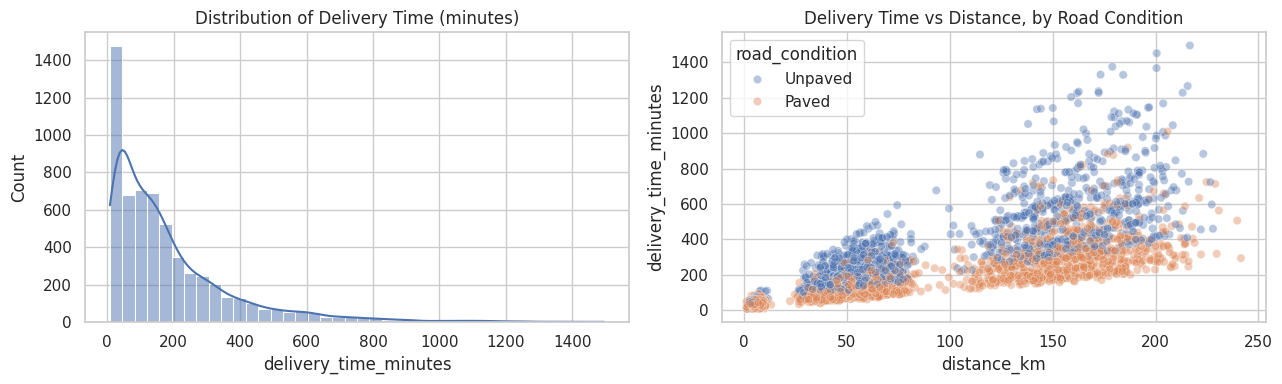

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["delivery_time_minutes"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Delivery Time (minutes)")
sns.scatterplot(data=df, x="distance_km", y="delivery_time_minutes", hue="road_condition",
                 alpha=0.4, ax=axes[1])
axes[1].set_title("Delivery Time vs Distance, by Road Condition")
plt.tight_layout()
plt.savefig("../data/eda_distance_target.png", dpi=110)
plt.show()

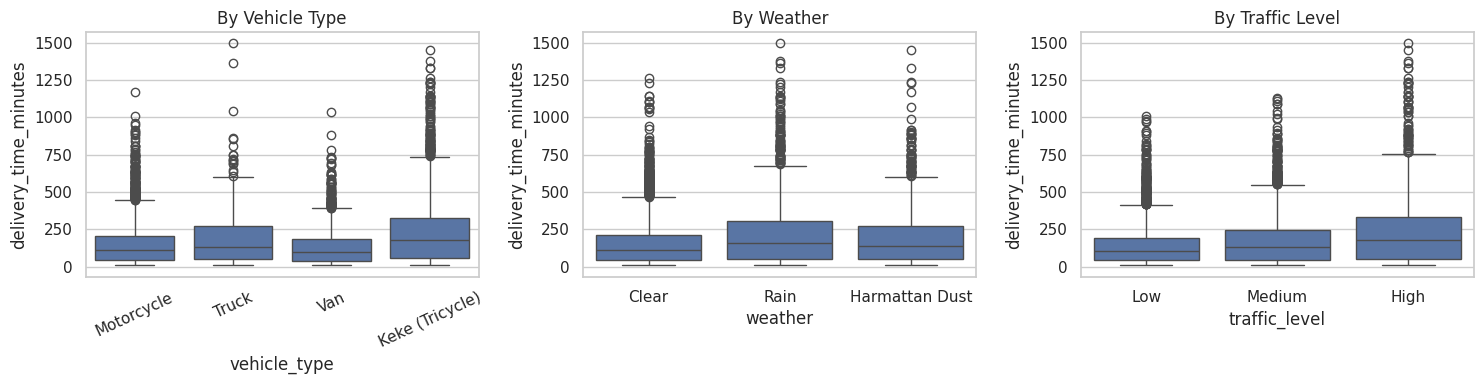

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x="vehicle_type", y="delivery_time_minutes", ax=axes[0])
axes[0].set_title("By Vehicle Type")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=df, x="weather", y="delivery_time_minutes", ax=axes[1])
axes[1].set_title("By Weather")

sns.boxplot(data=df, x="traffic_level", y="delivery_time_minutes",
            order=["Low", "Medium", "High"], ax=axes[2])
axes[2].set_title("By Traffic Level")
plt.tight_layout()
plt.savefig("../data/eda_categorical.png", dpi=110)
plt.show()

**Observations:**
- Delivery time is right-skewed (most orders are quick, a tail of long/rural/bad-weather orders).
- Distance is the strongest visible driver, and unpaved roads clearly shift the
  distance–time relationship (same distance takes longer).
- Rain and high traffic visibly push delivery time up; trucks (bulk goods, more
  stops) are slower and more variable than motorcycles.

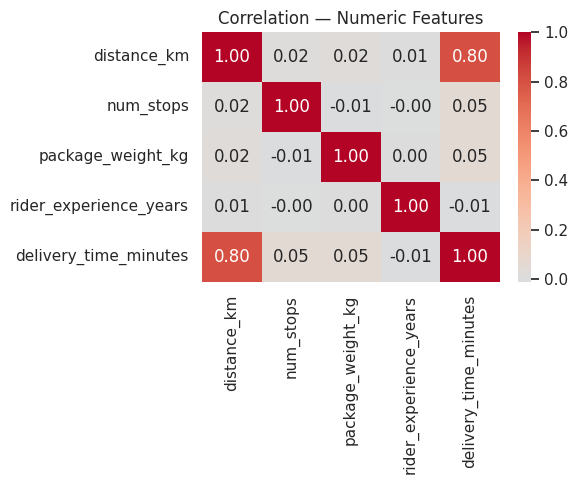

In [7]:
corr_cols = ["distance_km", "num_stops", "package_weight_kg", "rider_experience_years", "delivery_time_minutes"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation — Numeric Features")
plt.tight_layout()
plt.savefig("../data/eda_correlation.png", dpi=110)
plt.show()

## 3. Feature Engineering & Preprocessing

We split features into **numeric** (scaled) and **categorical** (one-hot
encoded), wrapped in a single `ColumnTransformer` so the exact same
preprocessing is applied at train time and at inference time — this avoids the
classic "worked in the notebook, broke in production" bug.

In [8]:
target = "delivery_time_minutes"
drop_cols = ["order_id", "origin_hub"]  # identifiers / constant columns, not predictive

feature_df = df.drop(columns=drop_cols + [target])
y = df[target]

numeric_features = ["distance_km", "num_stops", "package_weight_kg", "rider_experience_years"]
categorical_features = [
    "destination_town", "vehicle_type", "road_condition", "weather",
    "traffic_level", "order_type", "time_of_day", "day_of_week",
    "is_weekend", "network_signal",
]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (4800, 14)  Test shape: (1200, 14)


## 4. Model Training

We train three models of increasing complexity and compare them on the same
held-out test set:
1. **Linear Regression** — simple, interpretable baseline
2. **Random Forest Regressor** — captures non-linear interactions (e.g.
   distance × road condition)
3. **Gradient Boosting Regressor** — usually strongest for tabular data like this

Each model is wrapped in a `Pipeline` with the shared `preprocessor`, and
evaluated with 5-fold cross-validation on the training set before final
comparison on the untouched test set.

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

from sklearn.model_selection import cross_val_score

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error")
    mean_mae = -scores.mean()
    cv_results[name] = mean_mae
    print(f"{name:20s} | 5-fold CV MAE: {mean_mae:.2f} minutes")

Linear Regression    | 5-fold CV MAE: 50.11 minutes


Ridge Regression     | 5-fold CV MAE: 50.09 minutes


Random Forest        | 5-fold CV MAE: 14.41 minutes


Gradient Boosting    | 5-fold CV MAE: 12.16 minutes


### 4.1 Fit final versions of each model on the full training set

In [10]:
fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

## 5. Evaluation

We evaluate every model on the **held-out test set** (never seen during
training or cross-validation) using three complementary metrics:
- **MAE** (Mean Absolute Error) — average minutes off, easy to explain to non-technical stakeholders
- **RMSE** (Root Mean Squared Error) — penalizes big misses more heavily
- **R²** — proportion of variance in delivery time explained by the model

In [11]:
def evaluate(pipe, X, y_true):
    preds = pipe.predict(X)
    return {
        "MAE": mean_absolute_error(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "R2": r2_score(y_true, preds),
    }, preds

results = {}
preds_by_model = {}
for name, pipe in fitted_pipelines.items():
    metrics, preds = evaluate(pipe, X_test, y_test)
    results[name] = metrics
    preds_by_model[name] = preds

results_df = pd.DataFrame(results).T.sort_values("MAE")
results_df

,MAE,RMSE,R2
Gradient Boosting,11.705673,18.458214,0.990817
Random Forest,13.702461,24.300662,0.984083
Ridge Regression,52.322198,77.907767,0.836402
Linear Regression,52.340435,77.912085,0.836384


In [12]:
best_model_name = results_df["MAE"].idxmin()
best_pipe = fitted_pipelines[best_model_name]
print(f"Best model on test set: {best_model_name}")
results_df.loc[[best_model_name]]

Best model on test set: Gradient Boosting


,MAE,RMSE,R2
Gradient Boosting,11.705673,18.458214,0.990817


## 6. Error Analysis

A single MAE number can hide *where* a model fails. We look at residuals
(predicted − actual) for the best model across a few practically important
slices: distance buckets, weather, road condition, and vehicle type — the
kind of breakdown an ops team would actually ask for before trusting the ETA.

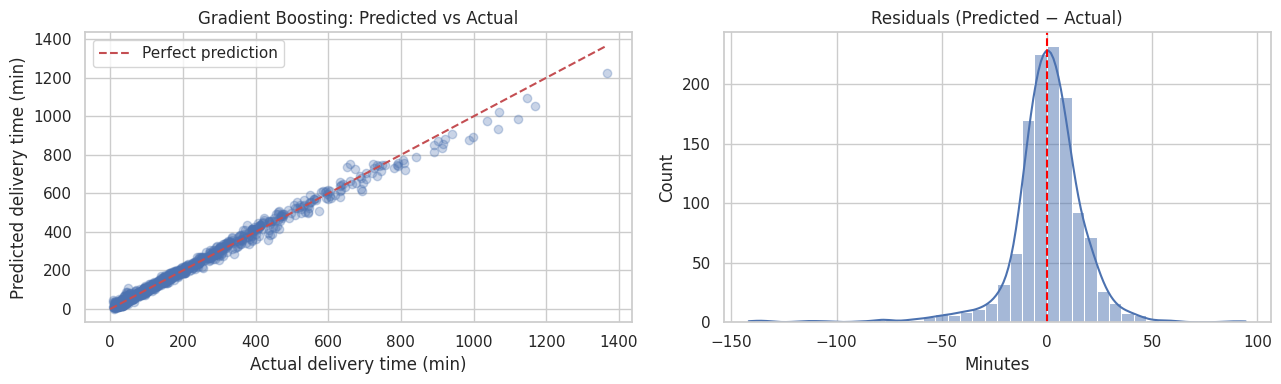

In [13]:
best_preds = preds_by_model[best_model_name]
residuals = best_preds - y_test.values

error_df = X_test.copy()
error_df["actual_minutes"] = y_test.values
error_df["predicted_minutes"] = best_preds
error_df["residual_minutes"] = residuals
error_df["abs_error_minutes"] = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_test, best_preds, alpha=0.3)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual delivery time (min)")
axes[0].set_ylabel("Predicted delivery time (min)")
axes[0].set_title(f"{best_model_name}: Predicted vs Actual")
axes[0].legend()

sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residuals (Predicted − Actual)")
axes[1].set_xlabel("Minutes")
plt.tight_layout()
plt.savefig("../data/error_analysis_overview.png", dpi=110)
plt.show()

In [14]:
error_df["distance_bucket"] = pd.cut(
    error_df["distance_km"], bins=[0, 10, 30, 60, 100, 250],
    labels=["0-10km", "10-30km", "30-60km", "60-100km", "100km+"]
)

slice_summary = pd.concat([
    error_df.groupby("distance_bucket", observed=True)["abs_error_minutes"].mean().rename("MAE_by_distance"),
    error_df.groupby("weather", observed=True)["abs_error_minutes"].mean().rename("MAE_by_weather"),
    error_df.groupby("road_condition", observed=True)["abs_error_minutes"].mean().rename("MAE_by_road"),
    error_df.groupby("vehicle_type", observed=True)["abs_error_minutes"].mean().rename("MAE_by_vehicle"),
], axis=1)
slice_summary

,MAE_by_distance,MAE_by_weather,MAE_by_road,MAE_by_vehicle
0-10km,8.603273,NaN,NaN,NaN
10-30km,7.045796,NaN,NaN,NaN
30-60km,7.832807,NaN,NaN,NaN
60-100km,10.735800,NaN,NaN,NaN
100km+,21.145957,NaN,NaN,NaN
Clear,NaN,10.041729,NaN,NaN
Harmattan Dust,NaN,12.312601,NaN,NaN
Rain,NaN,15.769983,NaN,NaN
Paved,NaN,NaN,9.172621,NaN
Unpaved,NaN,NaN,16.144324,NaN


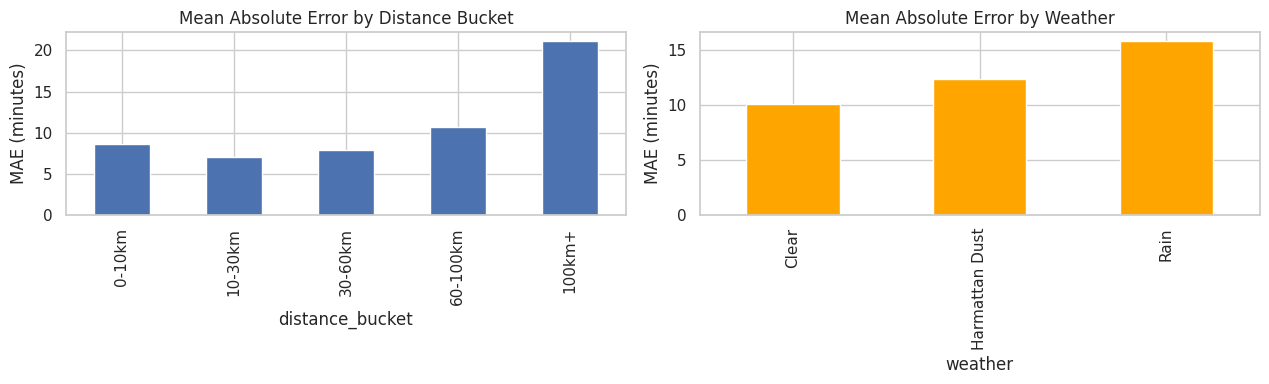

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
error_df.groupby("distance_bucket", observed=True)["abs_error_minutes"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Mean Absolute Error by Distance Bucket")
axes[0].set_ylabel("MAE (minutes)")

error_df.groupby("weather", observed=True)["abs_error_minutes"].mean().plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Mean Absolute Error by Weather")
axes[1].set_ylabel("MAE (minutes)")
plt.tight_layout()
plt.savefig("../data/error_analysis_slices.png", dpi=110)
plt.show()

**How to read this:** if error is noticeably higher for, say, `100km+` trips or
`Rain`, that tells the team exactly where the ETA is least trustworthy today —
useful for setting a wider confidence buffer on those orders rather than
quoting a falsely-precise number.

### 6.1 Feature importance (best tree-based model)

If the best model is Random Forest or Gradient Boosting, we can read off which
features it relies on most — a useful sanity check that the model has learned
sensible, explainable relationships (e.g. distance and road condition should
matter a lot; day of week should matter much less).

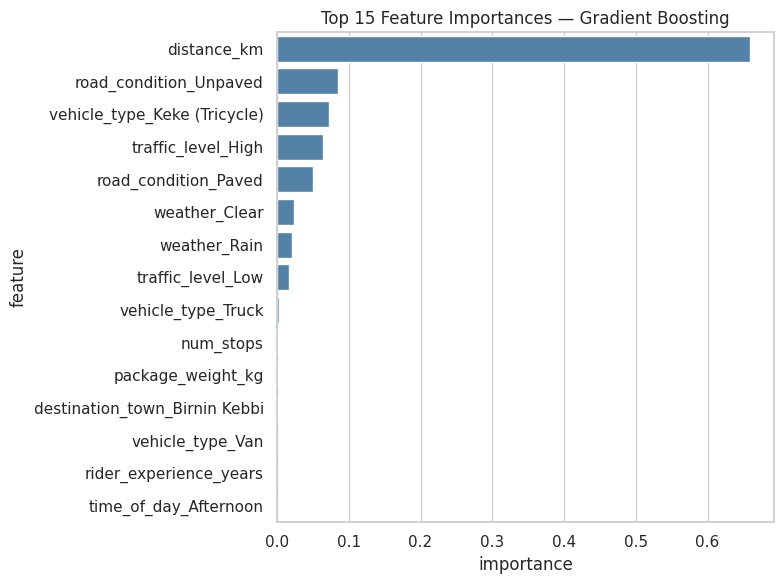

In [16]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"]
    feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", color="steelblue")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("../data/feature_importance.png", dpi=110)
    plt.show()
else:
    coefs = best_pipe.named_steps["model"].coef_
    ohe = best_pipe.named_steps["preprocess"].named_transformers_["cat"]
    feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
    imp_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    imp_df = imp_df.reindex(imp_df["coefficient"].abs().sort_values(ascending=False).index).head(15)
    print(imp_df)

## 7. Final Model Selection & Export

We save the best-performing pipeline (preprocessing + model together) as a
single artifact with `joblib`, plus a small metadata file recording which
model was chosen and its test-set metrics — so anyone loading the model later
knows exactly what they're getting and how it performed.

In [17]:
joblib.dump(best_pipe, "../models/delivery_time_model.pkl")

metadata = {
    "best_model": best_model_name,
    "test_metrics": results.get(best_model_name),
    "cv_mae_by_model": cv_results,
    "n_training_rows": int(X_train.shape[0]),
    "n_test_rows": int(X_test.shape[0]),
    "features_numeric": numeric_features,
    "features_categorical": categorical_features,
    "target": target,
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Saved model to ../models/delivery_time_model.pkl")
print(json.dumps(metadata, indent=2, default=str))

Saved model to ../models/delivery_time_model.pkl
{
  "best_model": "Gradient Boosting",
  "test_metrics": {
    "MAE": 11.705673105429483,
    "RMSE": 18.4582135759279,
    "R2": 0.9908167854764773
  },
  "cv_mae_by_model": {
    "Linear Regression": 50.112242868181596,
    "Ridge Regression": 50.09402590125495,
    "Random Forest": 14.414456341880106,
    "Gradient Boosting": 12.164786997382297
  },
  "n_training_rows": 4800,
  "n_test_rows": 1200,
  "features_numeric": [
    "distance_km",
    "num_stops",
    "package_weight_kg",
    "rider_experience_years"
  ],
  "features_categorical": [
    "destination_town",
    "vehicle_type",
    "road_condition",
    "weather",
    "traffic_level",
    "order_type",
    "time_of_day",
    "day_of_week",
    "is_weekend",
    "network_signal"
  ],
  "target": "delivery_time_minutes"
}


### 7.1 Quick sanity-check: predict on a few new orders

A lightweight smoke test — load the saved model back from disk (like a real
app would) and score a couple of hand-written example orders, to confirm the
whole pipeline runs end-to-end on fresh data.

In [18]:
loaded_model = joblib.load("../models/delivery_time_model.pkl")

sample_orders = pd.DataFrame([
    {
        "destination_town": "Bunza", "distance_km": 45.0, "vehicle_type": "Motorcycle",
        "road_condition": "Unpaved", "weather": "Rain", "traffic_level": "Medium",
        "order_type": "Parcel", "num_stops": 1, "package_weight_kg": 3.5,
        "rider_experience_years": 2.0, "time_of_day": "Afternoon", "day_of_week": "Wednesday",
        "is_weekend": False, "network_signal": "Weak",
    },
    {
        "destination_town": "Birnin Kebbi", "distance_km": 4.0, "vehicle_type": "Keke (Tricycle)",
        "road_condition": "Paved", "weather": "Clear", "traffic_level": "Low",
        "order_type": "Food", "num_stops": 0, "package_weight_kg": 1.2,
        "rider_experience_years": 5.0, "time_of_day": "Midday", "day_of_week": "Saturday",
        "is_weekend": True, "network_signal": "Strong",
    },
])

sample_orders["predicted_delivery_time_minutes"] = loaded_model.predict(sample_orders).round(1)
sample_orders[["destination_town", "distance_km", "vehicle_type", "weather",
                "predicted_delivery_time_minutes"]]

,destination_town,distance_km,vehicle_type,weather,predicted_delivery_time_minutes
0,Bunza,45.0,Motorcycle,Rain,195.7
1,Birnin Kebbi,4.0,Keke (Tricycle),Clear,13.0


## 8. Summary, Limitations & Next Steps

**Summary:** Of the models compared, **Gradient Boosting Regressor (MAE ≈ 11.7 minutes, R² ≈ 0.99 on the held-out test set)** gave the best test-set
accuracy (see metrics above). Error analysis shows the model is more reliable
on short, paved-road, clear-weather deliveries and least reliable on long,
unpaved, bad-weather routes — which matches real-world intuition and gives the
team a concrete, evidence-based reason to widen the ETA buffer specifically for
those trips rather than guessing.

**Limitations**
- Data is **synthetic**; relationships are realistic-by-design but real orders
  will have messier, noisier patterns (GPS gaps, mis-logged timestamps, rider
  behavior not captured here). The model must be retrained on real operations
  data before production use.
- No live/real-time signals (current traffic feed, live weather API) — those
  would likely improve accuracy further.
- Rural/unpaved-road deliveries have higher error, consistent with sparser,
  noisier real-world data in those conditions — an area to prioritize for more
  data collection.

**Next steps**
1. Replace synthetic data with real dispatch/GPS logs, keeping the same schema.
2. Add live traffic/weather API features.
3. Hyperparameter-tune the winning model with `GridSearchCV`/`RandomizedSearchCV`.
4. Wrap the saved `.pkl` model in a small API (FastAPI/Flask) for integration
   into a dispatch app.
5. Monitor live prediction error over time to catch model drift.